In [3]:
%pip install pandas


  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   --------- ------------------------------ 2.4/10.0 MB 15.6 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/10.0 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 16.7 MB/s  0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.6 MB 15.1 MB/s eta 0:00:01
   ------------------- -------------------- 6.3/12.6 MB 14.7 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.6 MB 12.6 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.6 MB 11.1 MB/s eta 0:00:01
   ---------------------------------- ----- 10.7/12.6 MB 9.9 MB/s eta 0:00:01
   -------------------------------------- - 12.1/12.6 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 9.1 MB/s  0:00:01
Using cached tzda

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.5 MB 10.6 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.5 MB 11.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 13.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 12.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------- ------------------------ 2.9/7.2 MB 15.3 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.2 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 14.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv("salesdaily.csv")

#print(data.head())
#print(data.columns)
#data.info()
#print(data.shape)
#print(data.isnull().sum())
print(data.describe())

Matplotlib is building the font cache; this may take a moment.


             M01AB        M01AE        N02BA        N02BE         N05B  \
count  2106.000000  2106.000000  2106.000000  2106.000000  2106.000000   
mean      5.033683     3.895830     3.880441    29.917095     8.853627   
std       2.737579     2.133337     2.384010    15.590966     5.605605   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       3.000000     2.340000     2.000000    19.000000     5.000000   
50%       4.990000     3.670000     3.500000    26.900000     8.000000   
75%       6.670000     5.138000     5.200000    38.300000    12.000000   
max      17.340000    14.463000    16.000000   161.000000    54.833333   

              N05C          R03          R06         Year        Month  \
count  2106.000000  2106.000000  2106.000000  2106.000000  2106.000000   
mean      0.593522     5.512262     2.900198  2016.401235     6.344255   
std       1.092988     6.428736     2.415816     1.665060     3.386954   
min       0.000000     0.000000     0

In [20]:
# Convert datum to datetime
data["datum"] = pd.to_datetime(data["datum"])

# Create Year and Month columns
data["Year"] = data["datum"].dt.year
data["Month"] = data["datum"].dt.month

print(data.head())

       datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0 2014-01-02    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1 2014-01-03    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2 2014-01-04    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3 2014-01-05    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4 2014-01-06    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  


In [21]:
drug_columns = [
    "M01AB",
    "M01AE",
    "N02BA",
    "N02BE",
    "N05B",
    "N05C",
    "R03",
    "R06"
]

In [22]:
total_sales = data[drug_columns].sum().sort_values(ascending=False)

print("Total sales for each drug category:")
print(total_sales)

Total sales for each drug category:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


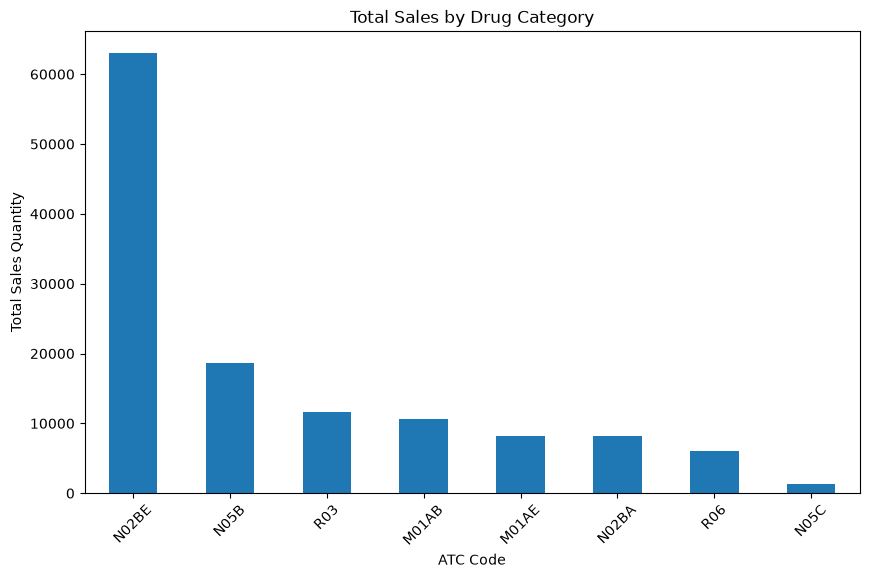

In [27]:
plt.figure(figsize=(10, 6))

total_sales.plot(kind="bar")

plt.title("Total Sales by Drug Category")
plt.xlabel("ATC Code")
plt.ylabel("Total Sales Quantity")
plt.xticks(rotation=45)

plt.show()

In [28]:
highest_sales = data[drug_columns].sum().sort_values(ascending=False)

print("Highest-selling drug categories:")
print(highest_sales)

Highest-selling drug categories:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


In [29]:
print("Top 3:")
print(highest_sales.head(3))

Top 3:
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
dtype: float64


In [30]:
def top_3_drugs(year, month):
    
    # Filter the requested year and month
    filtered_data = data[
        (data["Year"] == year) &
        (data["Month"] == month)
    ]
    
    # Calculate total sales for each drug
    sales = filtered_data[drug_columns].sum()
    
    # Sort and select top 3
    top_3 = sales.sort_values(ascending=False).head(3)
    
    print(f"\nTop 3 drugs in {month}/{year}:")
    print(top_3)

In [31]:
top_3_drugs(2015, 1)

top_3_drugs(2016, 7)

top_3_drugs(2017, 9)


Top 3 drugs in 1/2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

Top 3 drugs in 7/2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

Top 3 drugs in 9/2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [32]:
data_2017 = data[data["Year"] == 2017]

sales_2017 = data_2017[drug_columns].sum().sort_values(ascending=False)

print("Sales in 2017:")
print(sales_2017)

print("\nDrug with the highest sales in 2017:")
print(sales_2017.idxmax())

print("Sales quantity:")
print(sales_2017.max())

Sales in 2017:
N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64

Drug with the highest sales in 2017:
N02BE
Sales quantity:
9258.80483333


In [33]:
average_daily_sales = data[drug_columns].mean().sort_values(ascending=False)

print("Average daily sales:")
print(average_daily_sales)

print("\nCategory with highest average daily sales:")
print(average_daily_sales.idxmax())

print("Average daily sales:")
print(average_daily_sales.max())

Average daily sales:
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64

Category with highest average daily sales:
N02BE
Average daily sales:
29.917095303105413


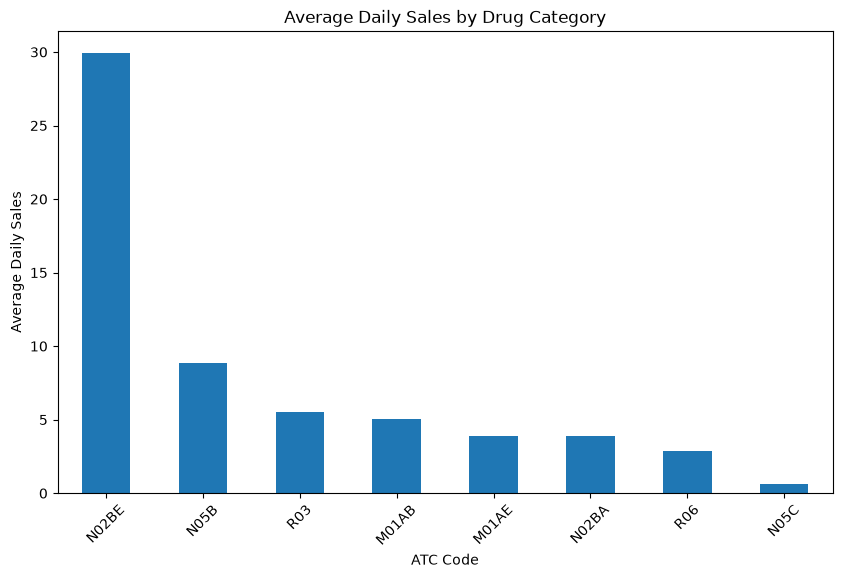

In [34]:
plt.figure(figsize=(10, 6))

average_daily_sales.plot(kind="bar")

plt.title("Average Daily Sales by Drug Category")
plt.xlabel("ATC Code")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)

plt.show()

In [35]:
r03_data = data[["datum", "Year", "Month", "R03"]]

print(r03_data.head())

      datum  Year  Month   R03
0  1/2/2014  2014      1   0.0
1  1/3/2014  2014      1  20.0
2  1/4/2014  2014      1   9.0
3  1/5/2014  2014      1   3.0
4  1/6/2014  2014      1   6.0


In [36]:
r03_monthly = r03_data.groupby("Month")["R03"].mean()

print("Average R03 sales by month:")
print(r03_monthly)

Average R03 sales by month:
Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64


In [37]:
r03_monthly_sorted = r03_monthly.sort_values(ascending=False)

print("Months with highest R03 average sales:")
print(r03_monthly_sorted)

Months with highest R03 average sales:
Month
12    7.916129
10    7.208589
2     6.896943
1     6.835980
3     6.290323
11    6.226667
4     5.771528
5     5.006944
9     4.402315
6     4.350000
8     3.102151
7     2.956989
Name: R03, dtype: float64


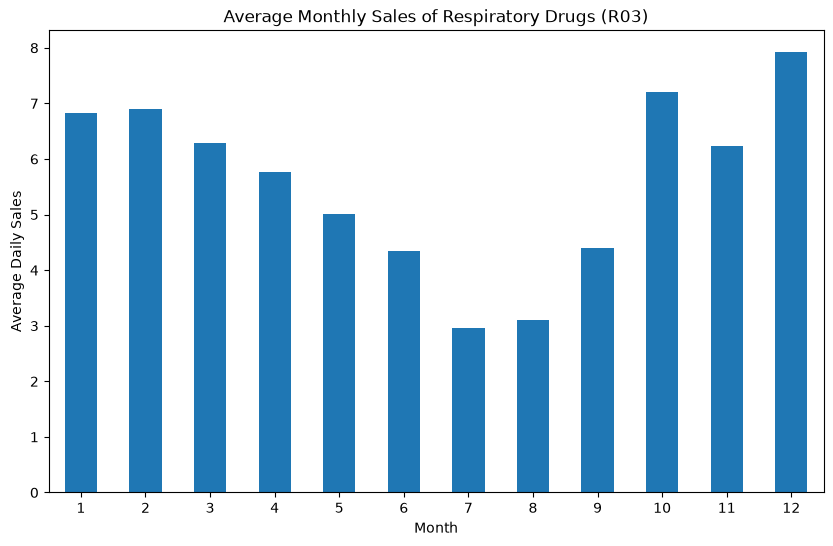

In [38]:
plt.figure(figsize=(10, 6))

r03_monthly.plot(kind="bar")

plt.title("Average Monthly Sales of Respiratory Drugs (R03)")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=0)

plt.show()